# Day 2: Dimensionality Reduction with PCA

<a target="_blank" href="https://colab.research.google.com/github/LuWidme/uk259/blob/main/demos/05_Dimensionality_Reduction.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

**Duration:** 1.5-2 hours  
**Prerequisites:** NumPy basics, Pandas fundamentals, data visualization  

**Learning Objectives:**
- Understand what dimensionality reduction is and why it matters
- Learn when to use PCA in real-world scenarios
- Apply sklearn's PCA to visualize high-dimensional data
- Determine the optimal number of components
- Use PCA as a preprocessing step for machine learning

**Datasets Used:** Iris dataset (4D), Wine dataset (13D)

**Note:** This notebook focuses on *using* PCA with sklearn. If you're interested in the mathematical details and implementing PCA from scratch, see the advanced notebook in `demos/advanced/`.

---

## What is Dimensionality Reduction?

**Simple explanation:** Dimensionality reduction is like taking a photo of a 3D object. You go from 3 dimensions to 2 dimensions, but you still capture most of the important information.

### The Problem: Too Many Features!

Imagine you have data about customers with 50 different features:
- Age, income, spending habits, browsing history, location data...
- That's 50 dimensions!
- Impossible to visualize
- Slow to process
- Hard to understand

**What if many of these features are related?**
- Age and "years until retirement" → basically the same thing
- "Number of purchases" and "total spending" → highly correlated
- We're wasting computational power on redundant information!

### The Solution: Dimensionality Reduction

**Goal:** Reduce 50 features → 2 or 3 features while keeping the most important patterns.

**Benefits:**
- ✓ **Visualize your data** - Plot in 2D or 3D
- ✓ **Faster training** - Fewer features = faster algorithms
- ✓ **Less storage** - Smaller datasets
- ✓ **Remove noise** - Filter out irrelevant variations
- ✓ **Avoid overfitting** - Simpler models generalize better

---

## What is PCA?

**PCA (Principal Component Analysis)** is the most popular dimensionality reduction technique.

### How PCA Works (Simple Explanation)

Think of your data as a cloud of points in space:

1. **Find the direction where data varies the most** → This becomes Principal Component 1 (PC1)
2. **Find the next best direction (perpendicular to PC1)** → This is PC2
3. **Continue for PC3, PC4, etc.**
4. **Keep only the top components** → Reduce dimensions!

**Real-world analogy:**

Imagine measuring the size of rectangles:
- You measure width AND diagonal AND area AND perimeter...
- But really, you only need **length** and **width** (2 dimensions)
- Everything else can be calculated from those two!
- PCA finds those fundamental "length and width" dimensions automatically

### When to Use PCA?

**✓ Good use cases:**
- Visualizing high-dimensional data (10+ features)
- Speeding up machine learning algorithms
- Reducing storage requirements
- Removing correlated features
- Image compression
- Face recognition ("Eigenfaces")

**✗ When NOT to use PCA:**
- Your features are already independent
- You need to interpret individual features (PCA creates new features)
- You have categorical data (PCA works on numbers)
- Non-linear patterns (use t-SNE or UMAP instead)

---

## Setup

Let's import the necessary libraries:

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn import datasets

# Set style
sns.set_style('whitegrid')
%matplotlib inline

# For reproducibility
np.random.seed(42)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


---

## Part 1: The Challenge - Visualizing 4D Data

Let's load the famous **Iris dataset** with 4 features:
1. Sepal length
2. Sepal width  
3. Petal length
4. Petal width

**Problem:** How do we visualize 4 dimensions?

In [55]:
# Load Iris dataset
iris = datasets.load_iris(as_frame=True)
X = iris.data  # 4 features
y = iris.target  # 3 species
target_names = iris.target_names

print("Dataset shape:", X.shape)
print("Features:", iris.feature_names)
print("\nFirst 5 rows:")
print(X.head())

print("\nChallenge: We have 4 features but can only plot in 2D or 3D!")

Dataset shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Challenge: We have 4 features but can only plot in 2D or 3D!


### Current Approach: Pairplot

One way is to look at all possible pairs of features:

<Figure size 1200x1000 with 0 Axes>

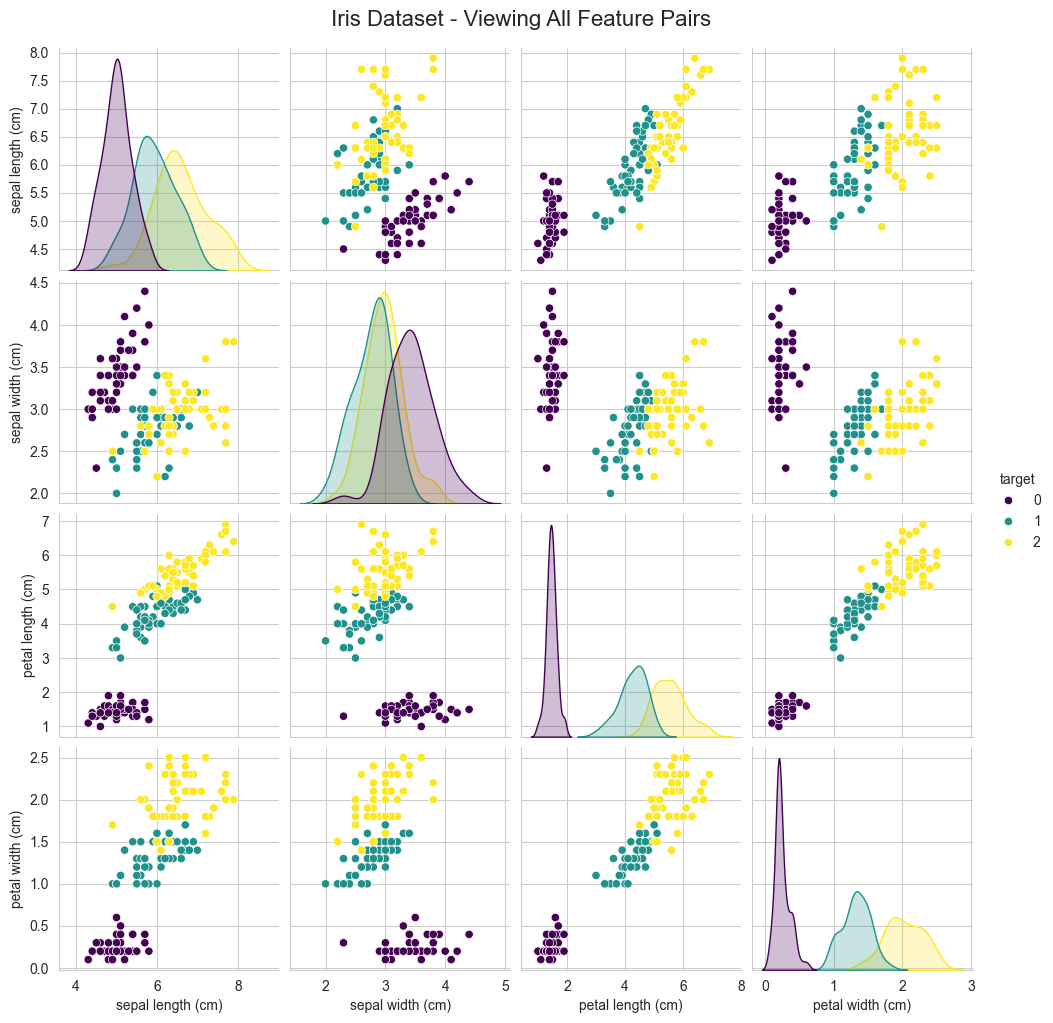


Problem: That's a lot of plots to look at!
With 4 features, we need 6 different 2D views.
With 50 features, we'd need 1,225 plots! 😱

Solution: Use PCA to reduce to just 2 dimensions!


In [56]:
# Create pairplot
plt.figure(figsize=(12, 10))
sns.pairplot(iris.frame, hue='target', palette='viridis', height=2.5)
plt.suptitle('Iris Dataset - Viewing All Feature Pairs', y=1.02, fontsize=16)
plt.show()

print("\nProblem: That's a lot of plots to look at!")
print("With 4 features, we need 6 different 2D views.")
print("With 50 features, we'd need 1,225 plots! 😱")
print("\nSolution: Use PCA to reduce to just 2 dimensions!")

---

## Part 2: Using PCA with Sklearn

### Step 1: Standardize the Data

**VERY IMPORTANT:** Always standardize your features before PCA!

**Why?** PCA is affected by the scale of features. If one feature is measured in millimeters and another in kilometers, PCA will think the kilometer feature is more important just because the numbers are bigger!

**Standardization:** Transform each feature to have mean=0 and standard deviation=1.

In [57]:
# Before standardization
print("Before standardization:")
print(X.describe().loc[['mean', 'std']])

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# After standardization
print("\nAfter standardization:")
X_scaled_df = pd.DataFrame(X_scaled, columns=iris.feature_names)
print(X_scaled_df.describe().loc[['mean', 'std']])

print("\n✓ All features now have mean ≈ 0 and std ≈ 1")

Before standardization:
      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
mean           5.843333          3.057333           3.758000          1.199333
std            0.828066          0.435866           1.765298          0.762238

After standardization:
      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
mean      -1.468455e-15     -1.823726e-15      -1.610564e-15     -9.473903e-16
std        1.003350e+00      1.003350e+00       1.003350e+00      1.003350e+00

✓ All features now have mean ≈ 0 and std ≈ 1


### Step 2: Apply PCA

Now let's reduce from 4D to 2D using PCA:

In [58]:
# Create PCA object
pca = PCA(n_components=2)  # Reduce to 2 dimensions

# Fit PCA and transform data
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("After PCA:", X_pca.shape)
print("\n✓ Successfully reduced from 4D to 2D!")

# How much information did we keep?
print("\nVariance explained by each component:")
for i, var in enumerate(pca.explained_variance_ratio_, 1):
    print(f"  PC{i}: {var:.1%}")

total_var = pca.explained_variance_ratio_.sum()
print(f"\nTotal variance preserved: {total_var:.1%}")
print(f"Information lost: {1-total_var:.1%}")

Original shape: (150, 4)
After PCA: (150, 2)

✓ Successfully reduced from 4D to 2D!

Variance explained by each component:
  PC1: 73.0%
  PC2: 22.9%

Total variance preserved: 95.8%
Information lost: 4.2%


## Part 4: Practical Exercise - Wine Dataset

Let's apply PCA to a more challenging dataset: **Wine** with **13 features**!

### Exercise: Reduce 13D Wine Data to 2D

**Task:** Apply PCA to visualize the wine dataset.

**Steps:**
1. Load the wine dataset
2. Standardize the features
3. Apply PCA to reduce to 2 components
4. Create a scree plot
5. Visualize the 2D projection

**Hints:**
- Use `load_wine(as_frame=True)` to load data
- Follow the same steps as the Iris example
- The wine dataset has 3 classes (wine types)

**Amazing!** We kept **97.8%** of the information while reducing from 4 dimensions to 2!

### Step 3: Visualize the Result

Now we can plot our 4D data in a simple 2D plot:

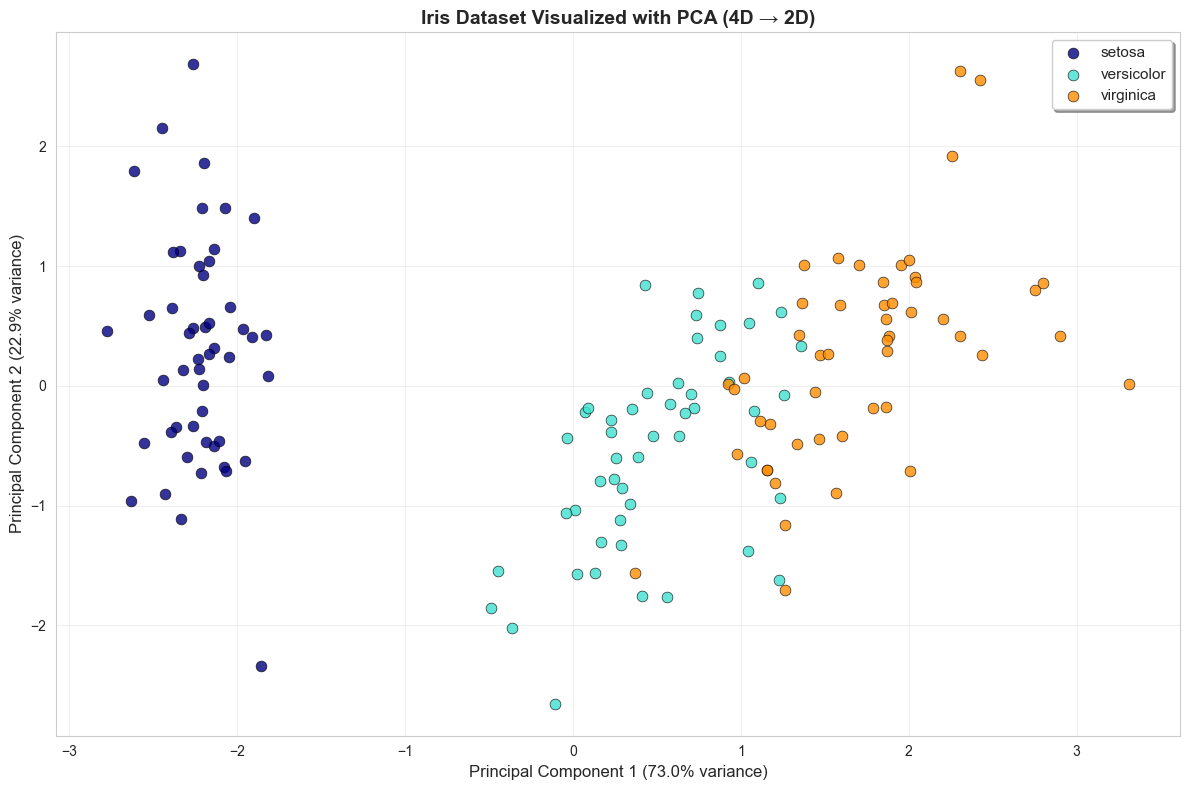


✓ We can now see all 4 dimensions in a single 2D plot!
✓ The three species are clearly separated.
✓ This would have been impossible without PCA.


In [59]:
# Create a beautiful 2D visualization
plt.figure(figsize=(12, 8))

colors = ['navy', 'turquoise', 'darkorange']
for i, (color, target_name) in enumerate(zip(colors, target_names)):
    plt.scatter(
        X_pca[y == i, 0],  # PC1
        X_pca[y == i, 1],  # PC2
        color=color,
        alpha=0.8,
        s=60,
        label=target_name,
        edgecolors='black',
        linewidth=0.5
    )

plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)',
           fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)',
           fontsize=12)
plt.title('Iris Dataset Visualized with PCA (4D → 2D)', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11, shadow=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ We can now see all 4 dimensions in a single 2D plot!")
print("✓ The three species are clearly separated.")
print("✓ This would have been impossible without PCA.")

---

## Part 3: How Many Components Should We Keep?

**Question:** Should we keep 1 component? 2? All 4?

### The Scree Plot

A **scree plot** shows how much variance each component explains. Look for an "elbow" where the curve flattens.

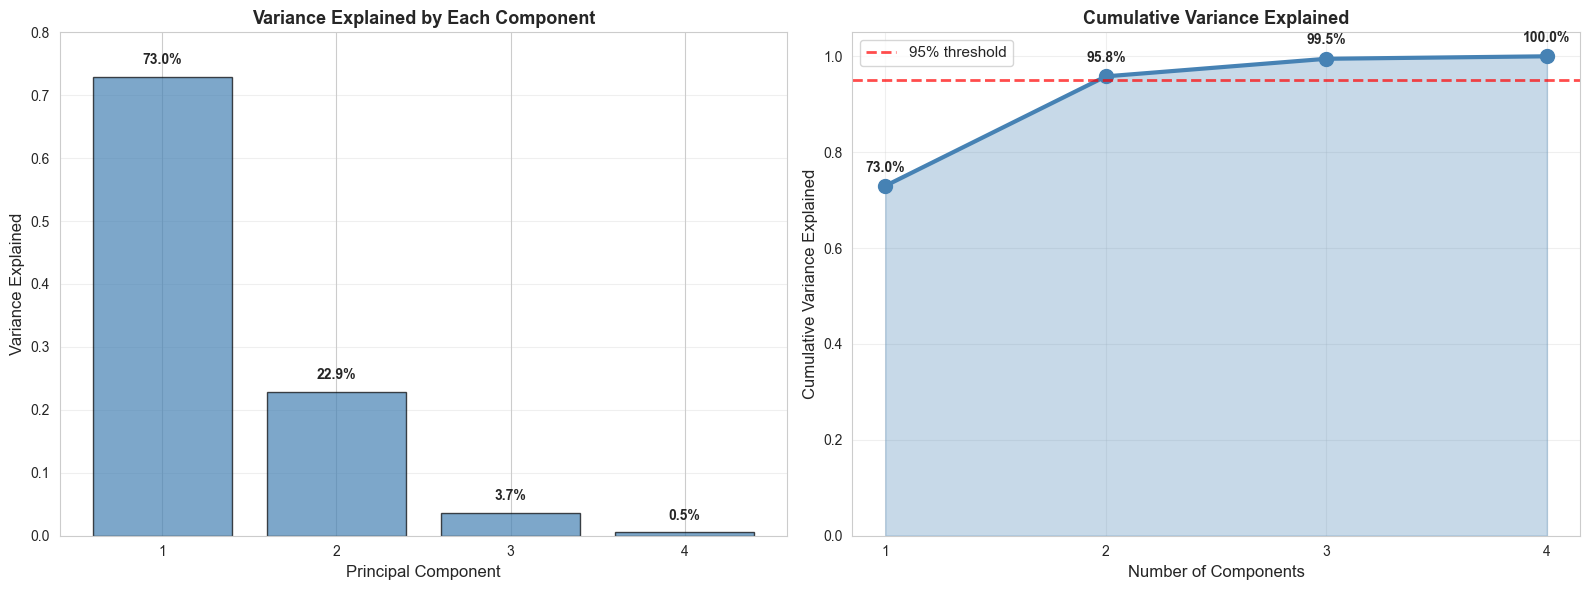


Variance Analysis:
PC1:  73.0% (cumulative:  73.0%)
PC2:  22.9% (cumulative:  95.8%)
PC3:   3.7% (cumulative:  99.5%)
PC4:   0.5% (cumulative: 100.0%)

📊 Interpretation:
  • PC1 alone captures 73.0% of variance
  • PC1 + PC2 capture 95.8% of variance
  • 2 components are enough to keep >95% of information!


In [60]:
# Fit PCA with all components
pca_full = PCA(n_components=4)
pca_full.fit(X_scaled)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Individual variance
axes[0].bar(range(1, 5), pca_full.explained_variance_ratio_,
            alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Variance Explained', fontsize=12)
axes[0].set_title('Variance Explained by Each Component', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(1, 5))
axes[0].set_ylim([0, 0.8])
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(pca_full.explained_variance_ratio_):
    axes[0].text(i+1, v+0.02, f'{v:.1%}', ha='center', fontweight='bold')

# Plot 2: Cumulative variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, 5), cumulative_variance, 'o-',
             linewidth=3, markersize=10, color='steelblue')
axes[1].axhline(y=0.95, color='red', linestyle='--', linewidth=2,
                alpha=0.7, label='95% threshold')
axes[1].fill_between(range(1, 5), cumulative_variance, alpha=0.3, color='steelblue')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Variance Explained', fontsize=12)
axes[1].set_title('Cumulative Variance Explained', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(1, 5))
axes[1].set_ylim([0, 1.05])
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# Add value labels
for i, v in enumerate(cumulative_variance):
    axes[1].text(i+1, v+0.03, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print analysis
print("\nVariance Analysis:")
print("=" * 50)
for i, (ind, cum) in enumerate(zip(pca_full.explained_variance_ratio_, cumulative_variance)):
    print(f"PC{i+1}: {ind:6.1%} (cumulative: {cum:6.1%})")

print("\n📊 Interpretation:")
print(f"  • PC1 alone captures {pca_full.explained_variance_ratio_[0]:.1%} of variance")
print(f"  • PC1 + PC2 capture {cumulative_variance[1]:.1%} of variance")
print(f"  • 2 components are enough to keep >95% of information!")

### Rule of Thumb

**Common strategies for choosing the number of components:**

1. **95% variance rule**: Keep enough components to explain 95% of variance
2. **Elbow method**: Look for the "elbow" where adding more components doesn't help much
3. **Fixed number**: Use 2-3 components for visualization, regardless of variance
4. **Cross-validation**: Test different numbers and see which gives best model performance

For Iris: **2 components** is perfect (97.8% variance + easy to visualize)

---

In [61]:
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
X_wine =  wine.data
y_wine =  wine.target

print(f"Wine dataset shape: {X_wine.shape}")
print(f"Number of features: {X_wine.shape[1]}")
print(f"\nFeatures: {wine.feature_names[:5]}...")

Wine dataset shape: (178, 13)
Number of features: 13

Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium']...


In [62]:
# TODO: Standardize the data Yes
scaler_wine = StandardScaler()
X_wine_scaled = scaler.fit_transform(X) # Use scaler_wine.fit_transform()


In [63]:
# TODO: Apply PCA with 2 components Yes
from sklearn.model_selection import train_test_split
pca_wine = PCA(n_components=2)
X_train, X_test, y_train, y_test = train_test_split(
    X_wine, y_wine, test_size=0.3, random_state=42
)
X_train_scaled2 = scaler2.fit_transform(X_train)
X_wine_pca = pca_wine.fit_transform(X_train_scaled2)


print(f"Original shape: {X_wine.shape}")
print(f"After PCA: {X_wine_pca.shape}")
print(f"\nVariance explained: {pca_wine.explained_variance_ratio_}")
print(f"Total: {pca_wine.explained_variance_ratio_.sum():.1%}")

Original shape: (178, 13)
After PCA: (124, 2)

Variance explained: [0.36196226 0.18763862]
Total: 55.0%


In [64]:
# TODO: Create scree plot (fit PCA with all 13 components first) Yes
pca_wine_full = PCA(n_components=13)
knn1.fit(X_train_scaled, y_train)

# Plot cumulative variance
plt.figure(figsize=(10, 6))
axes[1].plot(range(1, 5), cumulative_variance, 'o-',
             linewidth=3, markersize=10, color='steelblue')
plt.show()

<Figure size 1000x600 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

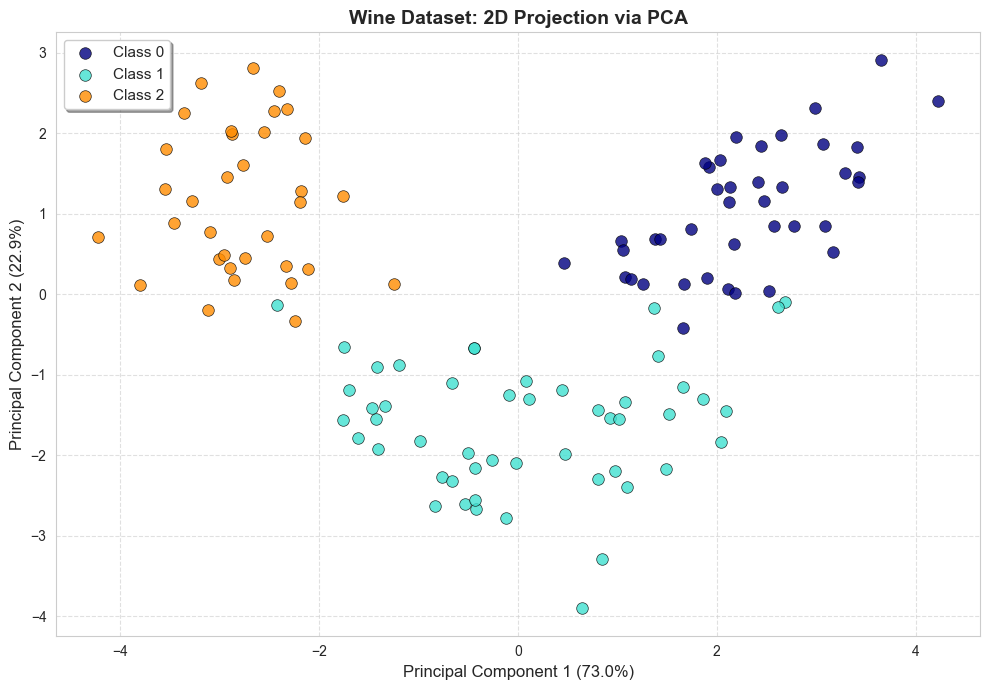

In [65]:
# TODO: Visualize 2D projection with wine classes
plt.figure(figsize=(12, 8))
# Your visualization code here

plt.figure(figsize=(10, 7))

colors = ['navy', 'turquoise', 'darkorange']
target_names = ['Class 0', 'Class 1', 'Class 2']

for i, color, name in zip([0, 1, 2], colors, target_names):
    plt.scatter(
        X_wine_pca[y_train == i, 0],  # PC1 (X-Achse)
        X_wine_pca[y_train == i, 1],  # PC2 (Y-Achse)
        color=color,
        alpha=0.8,
        s=70,
        label=name,
        edgecolors='black',
        linewidth=0.5
    )

plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)

plt.title('Wine Dataset: 2D Projection via PCA', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Hint: Use different colors for each wine class (0, 1, 2)
plt.show()

---

## Part 5: PCA in a Machine Learning Pipeline

PCA is often used as a **preprocessing step** before machine learning.

### Why use PCA before ML?

1. **Faster training** - Fewer features = faster algorithms
2. **Less overfitting** - Removing noisy dimensions helps generalization
3. **Handle multicollinearity** - Removes correlated features

### Example: Classification Pipeline

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_wine, y_wine, test_size=0.3, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

# Approach 1: Without PCA
print("\n=== Without PCA (13 features) ===")
scaler1 = StandardScaler()
X_train_scaled = scaler1.fit_transform(X_train)
X_test_scaled = scaler1.transform(X_test)

knn1 = KNeighborsClassifier(n_neighbors=5)
knn1.fit(X_train_scaled, y_train)
y_pred1 = knn1.predict(X_test_scaled)

acc1 = accuracy_score(y_test, y_pred1)
print(f"Accuracy: {acc1:.1%}")

# Approach 2: With PCA
print("\n=== With PCA (2 components) ===")
scaler2 = StandardScaler()
X_train_scaled2 = scaler2.fit_transform(X_train)
X_test_scaled2 = scaler2.transform(X_test)

pca2 = PCA(n_components=2)
X_train_pca = pca2.fit_transform(X_train_scaled2)
X_test_pca = pca2.transform(X_test_scaled2)

knn2 = KNeighborsClassifier(n_neighbors=5)
knn2.fit(X_train_pca, y_train)
y_pred2 = knn2.predict(X_test_pca)

acc2 = accuracy_score(y_test, y_pred2)
print(f"Accuracy: {acc2:.1%}")
print(f"Variance kept: {pca2.explained_variance_ratio_.sum():.1%}")

print("\n📊 Comparison:")
print(f"  Features reduced: 13 → 2 (85% reduction)")
print(f"  Accuracy change: {acc1:.1%} → {acc2:.1%}")
print(f"  Training speed: Much faster with 2 features!")

Training set size: (124, 13)
Test set size: (54, 13)

=== Without PCA (13 features) ===
Accuracy: 96.3%

=== With PCA (2 components) ===
Accuracy: 98.1%
Variance kept: 55.0%

📊 Comparison:
  Features reduced: 13 → 2 (85% reduction)
  Accuracy change: 96.3% → 98.1%
  Training speed: Much faster with 2 features!


### Important Notes:

**✓ DO:**
- Fit PCA on training data only
- Transform both training and test data using the same PCA
- Always standardize before PCA

**✗ DON'T:**
- Fit PCA on test data (data leakage!)
- Skip standardization
- Apply PCA to categorical variables

---

## Part 6: When PCA Works Well vs. Poorly

### PCA Works Great When:

**1. Features are correlated**

In [69]:
# Example: Highly correlated features
np.random.seed(42)
x1 = np.random.randn(100)
x2 = x1 + np.random.randn(100) * 0.1  # x2 ≈ x1 (highly correlated)
X_corr = np.column_stack([x1, x2])

# Apply PCA
pca_corr = PCA(n_components=2)
X_corr_pca = pca_corr.fit_transform(X_corr)

print("Correlated features:")
print(f"  PC1 explains: {pca_corr.explained_variance_ratio_[0]:.1%}")
print(f"  PC2 explains: {pca_corr.explained_variance_ratio_[1]:.1%}")
print("\n→ PC1 captures almost all information!")
print("  We can reduce 2D → 1D with minimal loss.")

Correlated features:
  PC1 explains: 99.7%
  PC2 explains: 0.3%

→ PC1 captures almost all information!
  We can reduce 2D → 1D with minimal loss.


**2. Data has linear structure**

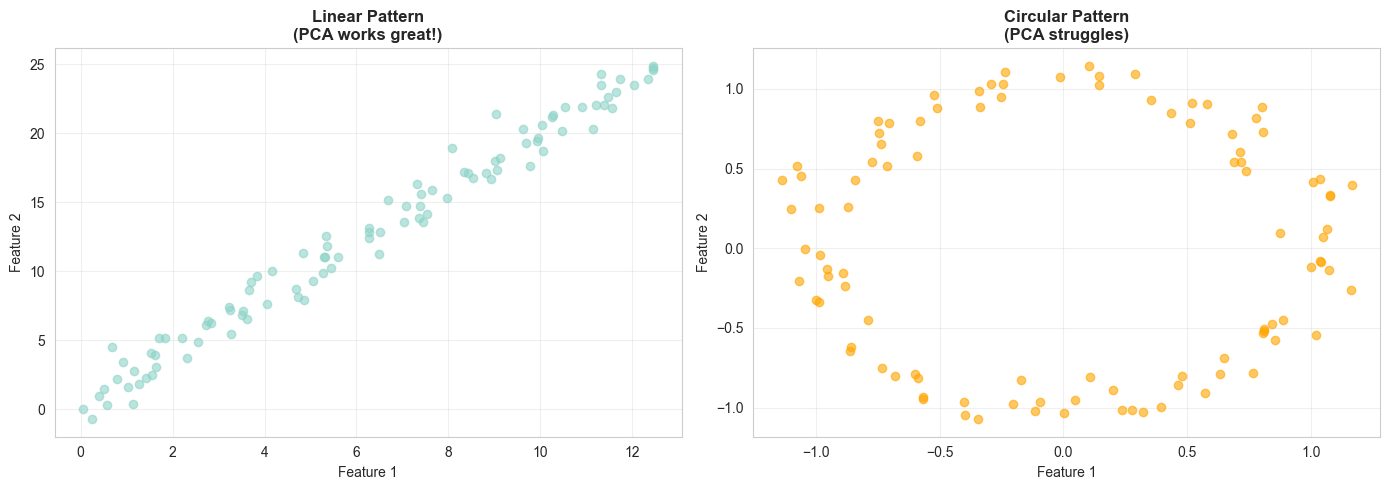


📌 Key insight:
  • PCA finds LINEAR patterns
  • For circular/spiral/complex patterns, use t-SNE or UMAP


In [70]:
# Visualize: Linear vs Non-linear data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear structure (PCA works well)
np.random.seed(42)
t = np.linspace(0, 4*np.pi, 100)
x_linear = t + np.random.randn(100) * 0.5
y_linear = 2*t + np.random.randn(100) * 0.5
axes[0].scatter(x_linear, y_linear, alpha=0.6)
axes[0].set_title('Linear Pattern\n(PCA works great!)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].grid(True, alpha=0.3)

# Non-linear structure (PCA struggles)
t = np.linspace(0, 4*np.pi, 100)
x_circle = np.cos(t) + np.random.randn(100) * 0.1
y_circle = np.sin(t) + np.random.randn(100) * 0.1
axes[1].scatter(x_circle, y_circle, alpha=0.6, color='orange')
axes[1].set_title('Circular Pattern\n(PCA struggles)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📌 Key insight:")
print("  • PCA finds LINEAR patterns")
print("  • For circular/spiral/complex patterns, use t-SNE or UMAP")

### Summary: PCA Best Practices

| Do ✓ | Don't ✗ |
|------|----------|
| Standardize features first | Skip StandardScaler |
| Use scree plot to choose components | Arbitrarily pick a number |
| Fit on training data only | Fit on test data |
| Check variance explained | Assume you kept enough info |
| Use for visualization & speed | Use when you need interpretable features |
| Apply to numerical data | Apply to categorical data |

---

## Summary

Congratulations! You've learned:

✓ What dimensionality reduction is and why it's useful  
✓ How PCA works conceptually (without complex math)  
✓ How to apply PCA using sklearn  
✓ How to choose the number of components  
✓ How to visualize high-dimensional data in 2D  
✓ How to use PCA in a machine learning pipeline  
✓ When PCA works well vs. poorly  

### Key Takeaways:

1. **PCA reduces dimensions while keeping important patterns**
2. **Always standardize your data first** (`StandardScaler`)
3. **Use scree plots to choose components** (aim for 95% variance)
4. **PCA is great for visualization** (reduce to 2D or 3D)
5. **PCA can speed up machine learning** (fewer features)
6. **PCA assumes linear patterns** (use t-SNE/UMAP for complex data)

### What's Next?

- **Practice:** Apply PCA to your own datasets
- **Explore:** Try t-SNE or UMAP for non-linear patterns
- **Advanced:** Check out `demos/advanced/` for mathematical implementation
- **Combine:** Use PCA with clustering, classification, or regression

### Additional Resources:

- [Scikit-learn PCA Guide](https://scikit-learn.org/stable/modules/decomposition.html#pca)
- [StatQuest: PCA Explained Simply](https://www.youtube.com/watch?v=FgakZw6K1QQ)
- [Interactive PCA Visualization](http://setosa.io/ev/principal-component-analysis/)
- [When to use PCA vs t-SNE](https://towardsdatascience.com/pca-vs-t-sne-8ba043f5759)

---

**Want to learn the math behind PCA?** Check out the advanced notebook: `demos/advanced/05_Dimensionality_Reduction_Advanced.ipynb`

In [12]:
import pandas as pd

df = pd.read_csv('../datasets/Iran.csv', sep=';')

df.set_index('Indicator Name', inplace=True)

if 'Indicator Code' in df.columns:
    df.drop(columns=['Indicator Code'], inplace=True)

df_final = df.T

df_final.index.name = 'Year'
df_final.index = pd.to_numeric(df_final.index, errors='coerce')

print(df_final.head())

Indicator Name  Merchandise imports by the reporting economy (current US$)  \
Year                                                                         
1960                                                  556900000.0            
1961                                                  601500000.0            
1962                                                  520600000.0            
1963                                                  520000000.0            
1964                                                  668900000.0            

Indicator Name  Merchandise imports from low- and middle-income economies in Middle East & North Africa (% of total merchandise imports)  \
Year                                                                                                                                       
1960                                                     1.687915                                                                          
1961                             

Datei erfolgreich geladen.


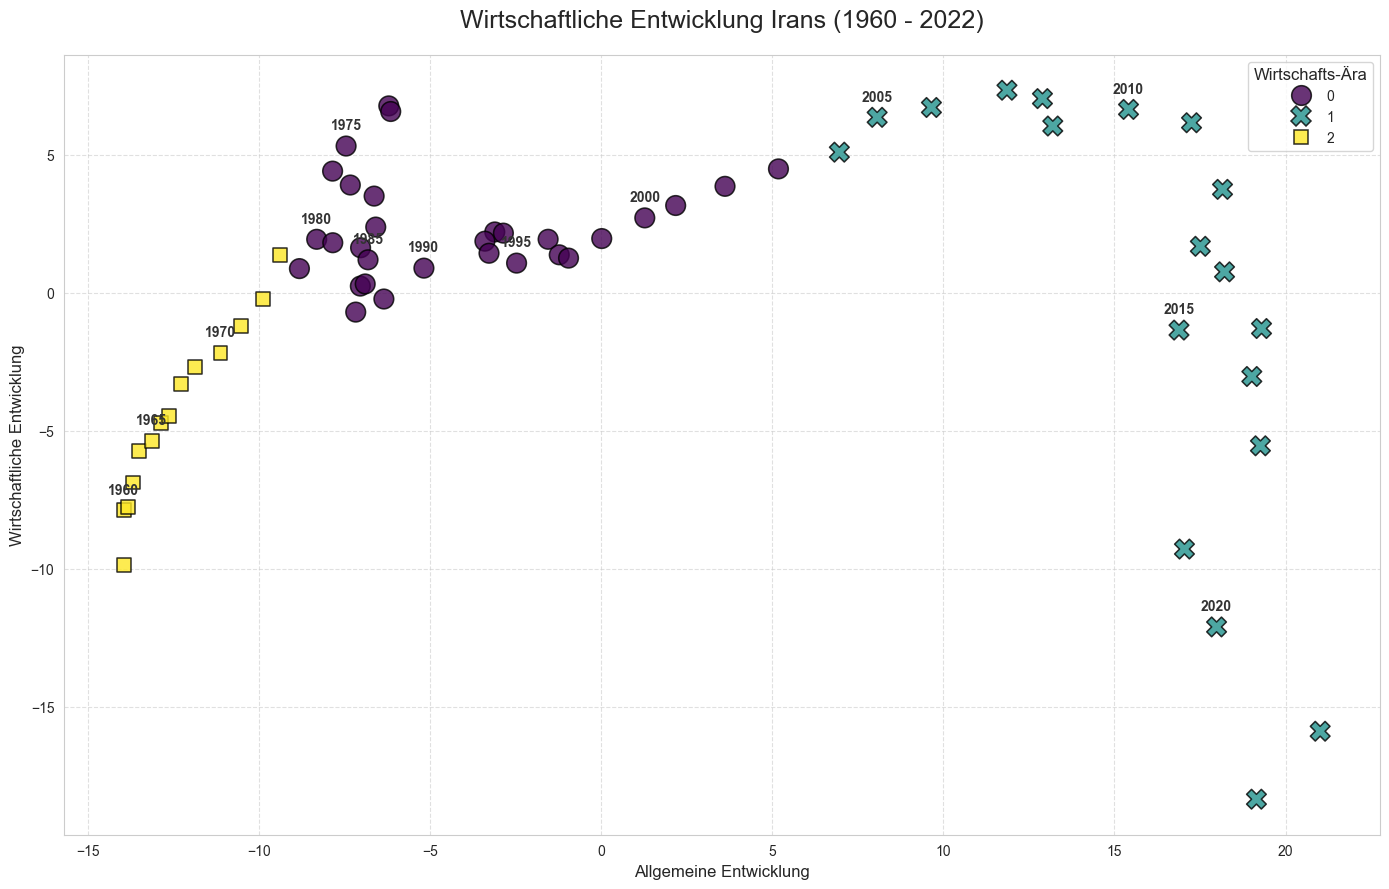

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

try:
    df = pd.read_csv('../datasets/Iran.csv', sep=';')
    print("Datei erfolgreich geladen.")
except FileNotFoundError:
    print("OHHH NEIIINNNN.")

df = df.set_index('Indicator Name')
if 'Indicator Code' in df.columns:
    df = df.drop(columns=['Indicator Code'])

df_transformed = df.T
df_transformed.index.name = 'Year'

df_transformed.index = pd.to_numeric(df_transformed.index, errors='coerce')
df_transformed = df_transformed.apply(pd.to_numeric, errors='coerce')

df_cleaned = df_transformed.fillna(df_transformed.mean())

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cleaned)

pca = PCA(n_components=2)
pca_results = pca.fit_transform(scaled_data)

df_pca = pd.DataFrame(
    data=pca_results,
    columns=['PC1', 'PC2'],
    index=df_cleaned.index
)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_pca['Cluster'] = kmeans.fit_predict(scaled_data)

plt.figure(figsize=(14, 9))
sns.set_style("whitegrid")


plot = sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='viridis',
    s=200,
    style='Cluster',
    edgecolor='black',
    alpha=0.8
)

for year, row in df_pca.iterrows():
    if int(year) % 5 == 0:
        plt.annotate(
            int(year),
            (row['PC1'], row['PC2']),
            textcoords="offset points",
            xytext=(0,12),
            ha='center',
            fontsize=10,
            fontweight='bold',
            color='#333333'
        )


plt.title('Wirtschaftliche Entwicklung Irans (1960 - 2022)', fontsize=18, pad=20)
plt.xlabel('Allgemeine Entwicklung', fontsize=12)
plt.ylabel('Wirtschaftliche Entwicklung', fontsize=12)
plt.legend(title='Wirtschafts-Ära', title_fontsize='12', loc='best')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()